In [2]:
# ===============================
# 1. Import Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC

from sklearn.metrics import make_scorer, mean_squared_error, r2_score, accuracy_score, f1_score

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

In [3]:
# Load dataset
df = pd.read_csv("Dataset.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 13)


In [4]:
df.head()

,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


In [5]:
# Number of samples and features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1]-2)

# Target distribution
print("\nClassification Target Distribution")
print(df['Performance_Level_Classification'].value_counts())

Number of samples: 1000
Number of features: 11

Classification Target Distribution
Performance_Level_Classification
Medium    545
Low       253
High      202
Name: count, dtype: int64


In [6]:
# ── 2a. Identify target columns ──────────────────────────────
# Adjust these column names if your CSV uses different names
REGRESSION_TARGET    = "Final Score"        # continuous target
CLASSIFICATION_TARGET = "Performance Level" # categorical target

In [7]:
# Auto-detect if column names differ
all_cols = df.columns.tolist()
if REGRESSION_TARGET not in all_cols:
    # Try to find a numeric column that could be regression target
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    REGRESSION_TARGET = num_cols[-1]
    print(f"[Auto-detected] Regression target    : '{REGRESSION_TARGET}'")
 
if CLASSIFICATION_TARGET not in all_cols:
    # Try to find a categorical/object column
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    if cat_cols:
        CLASSIFICATION_TARGET = cat_cols[-1]
    else:
        # Fall back to binning the regression target
        CLASSIFICATION_TARGET = "Performance_Level_Binned"
        df[CLASSIFICATION_TARGET] = pd.qcut(
            df[REGRESSION_TARGET], q=3, labels=["Low", "Medium", "High"]
        )
    print(f"[Auto-detected] Classification target: '{CLASSIFICATION_TARGET}'")
 
print(f"\nRegression    target : '{REGRESSION_TARGET}'")
print(f"Classification target: '{CLASSIFICATION_TARGET}'")

[Auto-detected] Regression target    : 'Final_Score_Regression'
[Auto-detected] Classification target: 'Performance_Level_Classification'

Regression    target : 'Final_Score_Regression'
Classification target: 'Performance_Level_Classification'


In [8]:
# ── 2b. Separate feature columns ─────────────────────────────
drop_cols = [REGRESSION_TARGET, CLASSIFICATION_TARGET]
drop_cols = [c for c in drop_cols if c in df.columns]
X_raw = df.drop(columns=drop_cols)
 
y_reg  = df[REGRESSION_TARGET].copy()
y_clf  = df[CLASSIFICATION_TARGET].copy()

In [9]:
# ── 2c. Handle missing values ────────────────────────────────
missing_before = X_raw.isnull().sum().sum()
print(f"\nMissing values before imputation : {missing_before}")


Missing values before imputation : 0


In [10]:
# Numeric columns → median imputation
num_feat = X_raw.select_dtypes(include=[np.number]).columns
X_raw[num_feat] = X_raw[num_feat].fillna(X_raw[num_feat].median())

In [11]:
# Categorical columns → mode imputation then encode
cat_feat = X_raw.select_dtypes(include=["object", "category"]).columns
for col in cat_feat:
    X_raw[col] = X_raw[col].fillna(X_raw[col].mode()[0])
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
 
y_reg = y_reg.fillna(y_reg.median())
 
missing_after = X_raw.isnull().sum().sum()
print(f"Missing values after  imputation : {missing_after}")

Missing values after  imputation : 0


In [12]:
# ── 2d. Encode classification target ────────────────────────
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf.astype(str))
print(f"\nClassification classes : {list(le.classes_)}")


Classification classes : ['High', 'Low', 'Medium']


In [13]:
# ── 2e. Dataset statistics ───────────────────────────────────
print(f"\nFeature matrix shape  : {X_raw.shape}")
print(f"\nRegression target distribution:")
print(f"  Mean={y_reg.mean():.2f}, Std={y_reg.std():.2f}, "
      f"Min={y_reg.min():.2f}, Max={y_reg.max():.2f}")
print(f"\nClassification target distribution:")
for cls, cnt in zip(le.classes_, np.bincount(y_clf_enc)):
    print(f"  {cls}: {cnt} samples ({100*cnt/len(y_clf_enc):.1f}%)")


Feature matrix shape  : (1000, 11)

Regression target distribution:
  Mean=66.62, Std=10.24, Min=37.23, Max=111.59

Classification target distribution:
  High: 202 samples (20.2%)
  Low: 253 samples (25.3%)
  Medium: 545 samples (54.5%)


In [14]:
# ── 2f. Standardize features ─────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)
print(f"\nStandardization applied — mean≈{X_scaled.values.mean():.4f}, "
      f"std≈{X_scaled.values.std():.4f}")


Standardization applied — mean≈0.0000, std≈1.0000


In [15]:
# SECTION 3: PCA IMPLEMENTATION

# Full PCA to study explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
 
explained_var       = pca_full.explained_variance_ratio_
cumulative_var      = np.cumsum(explained_var)
n_components_95     = np.argmax(cumulative_var >= 0.95) + 1
n_features          = X_scaled.shape[1]
 
print(f"Total features               : {n_features}")
print(f"Components for 95% variance  : {n_components_95}")
print(f"Explained variance at 95% PC : {cumulative_var[n_components_95-1]*100:.2f}%")

Total features               : 11
Components for 95% variance  : 7
Explained variance at 95% PC : 95.90%


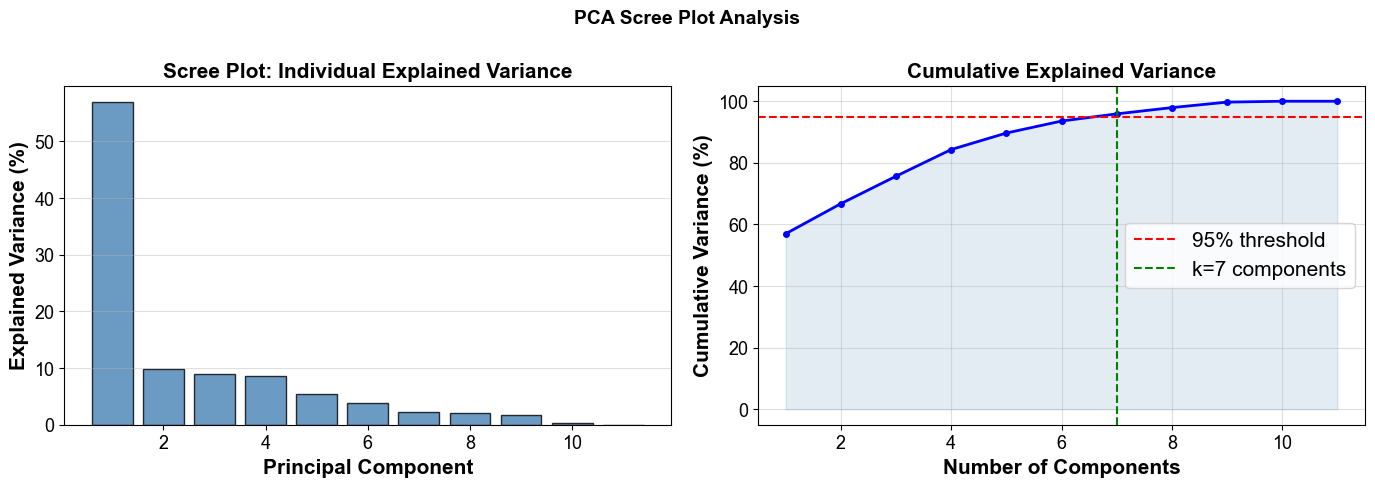

Saved: pca_scree_plot.png


In [16]:
# ── 3a. Scree Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].bar(range(1, min(21, n_features+1)),
            explained_var[:20] * 100,
            color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Scree Plot: Individual Explained Variance", fontweight="bold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].grid(axis="y", alpha=0.4)
 
axes[1].plot(range(1, n_features+1), cumulative_var * 100,
             "bo-", markersize=4, linewidth=2)
axes[1].axhline(y=95, color="red", linestyle="--", linewidth=1.5, label="95% threshold")
axes[1].axvline(x=n_components_95, color="green", linestyle="--",
                linewidth=1.5, label=f"k={n_components_95} components")
axes[1].fill_between(range(1, n_features+1), cumulative_var * 100,
                     alpha=0.15, color="steelblue")
axes[1].set_title("Cumulative Explained Variance", fontweight="bold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()
axes[1].grid(alpha=0.4)
 
plt.suptitle("PCA Scree Plot Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")

In [17]:
# ── 3b. Apply PCA (retain 95% variance) ─────────────────────
pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components_95)])
 
print(f"\nTable 1: PCA Summary")
print(f"{'Components Chosen':<22} {n_components_95}")
print(f"{'Explained Variance (%)':<22} {cumulative_var[n_components_95-1]*100:.2f}%")
print(f"{'Justification':<22} Retain 95% of total variance with minimal information loss.")
 
X_no_pca = X_scaled   # Original scaled features
X_with_pca = X_pca    # PCA-reduced features


Table 1: PCA Summary
Components Chosen      7
Explained Variance (%) 95.90%
Justification          Retain 95% of total variance with minimal information loss.


In [18]:
# SECTION 4: CROSS-VALIDATION SETUP
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
def cv_regression(model, X, y, kf):
    """Return per-fold MSE and R2."""
    mse_folds, r2_folds = [], []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        mse_folds.append(mean_squared_error(y_te, y_pred))
        r2_folds.append(r2_score(y_te, y_pred))
    return np.array(mse_folds), np.array(r2_folds)
 

In [20]:
def cv_classification(model, X, y, kf):
    """Return per-fold Accuracy and F1."""
    acc_folds, f1_folds = [], []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        acc_folds.append(accuracy_score(y_te, y_pred))
        f1_folds.append(f1_score(y_te, y_pred, average="weighted", zero_division=0))
    return np.array(acc_folds), np.array(f1_folds)
 
y_reg_s  = pd.Series(y_reg.values)
y_clf_s  = np.array(y_clf_enc)

In [21]:
# SECTION 5: REGRESSION MODELS

# ── 5a. Linear Regression ────────────────────────────────────
print("\n--- Linear Regression ---")
lr = LinearRegression()
 
lr_mse_no,  lr_r2_no  = cv_regression(lr, X_no_pca,   y_reg_s, kf)
lr_mse_pca, lr_r2_pca = cv_regression(lr, X_with_pca, y_reg_s, kf)
 
print(f"  No PCA  — MSE: {lr_mse_no.mean():.4f} ± {lr_mse_no.std():.4f}  "
      f"R²: {lr_r2_no.mean():.4f} ± {lr_r2_no.std():.4f}")
print(f"  With PCA— MSE: {lr_mse_pca.mean():.4f} ± {lr_mse_pca.std():.4f}  "
      f"R²: {lr_r2_pca.mean():.4f} ± {lr_r2_pca.std():.4f}")


--- Linear Regression ---
  No PCA  — MSE: 26.2338 ± 1.9532  R²: 0.7479 ± 0.0165
  With PCA— MSE: 26.2251 ± 2.1705  R²: 0.7481 ± 0.0176


In [22]:
# ── 5b. Random Forest Regressor ──────────────────────────────
print("\n--- Random Forest Regressor (n_estimators=100, max_depth=10) ---")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
 
rf_mse_no,  rf_r2_no  = cv_regression(rf, X_no_pca,   y_reg_s, kf)
rf_mse_pca, rf_r2_pca = cv_regression(rf, X_with_pca, y_reg_s, kf)
 
print(f"  No PCA  — MSE: {rf_mse_no.mean():.4f} ± {rf_mse_no.std():.4f}  "
      f"R²: {rf_r2_no.mean():.4f} ± {rf_r2_no.std():.4f}")
print(f"  With PCA— MSE: {rf_mse_pca.mean():.4f} ± {rf_mse_pca.std():.4f}  "
      f"R²: {rf_r2_pca.mean():.4f} ± {rf_r2_pca.std():.4f}")


--- Random Forest Regressor (n_estimators=100, max_depth=10) ---
  No PCA  — MSE: 28.9206 ± 2.5182  R²: 0.7225 ± 0.0139
  With PCA— MSE: 28.7573 ± 2.7682  R²: 0.7241 ± 0.0187


In [23]:
# ── Table 2 ───────────────────────────────────────────────────
print("\n\nTable 2: 5-Fold CV Results — Regression")
print(f"{'Model':<22} {'Metric':<8} {'Fold Avg (No PCA)':>20} {'Fold Avg (With PCA)':>22} Observation")
print("-" * 100)
 
reg_rows = [
    ("Linear Regression", "MSE", lr_mse_no.mean(), lr_mse_pca.mean(),
     "PCA may reduce MSE by removing multicollinear features"),
    ("Linear Regression", "R²",  lr_r2_no.mean(),  lr_r2_pca.mean(),
     "R² typically stable or improved with PCA"),
    ("Random Forest",     "MSE", rf_mse_no.mean(), rf_mse_pca.mean(),
     "RF less sensitive to PCA; may slightly worsen"),
    ("Random Forest",     "R²",  rf_r2_no.mean(),  rf_r2_pca.mean(),
     "Tree models handle raw features well"),
]
for row in reg_rows:
    model, metric, no_pca, with_pca, obs = row
    print(f"{model:<22} {metric:<8} {no_pca:>20.4f} {with_pca:>22.4f}  {obs}")



Table 2: 5-Fold CV Results — Regression
Model                  Metric      Fold Avg (No PCA)    Fold Avg (With PCA) Observation
----------------------------------------------------------------------------------------------------
Linear Regression      MSE                   26.2338                26.2251  PCA may reduce MSE by removing multicollinear features
Linear Regression      R²                     0.7479                 0.7481  R² typically stable or improved with PCA
Random Forest          MSE                   28.9206                28.7573  RF less sensitive to PCA; may slightly worsen
Random Forest          R²                     0.7225                 0.7241  Tree models handle raw features well


In [24]:
# ── Per-fold detail ───────────────────────────────────────────
print("\nPer-Fold MSE — Linear Regression:")
for i, (a, b) in enumerate(zip(lr_mse_no, lr_mse_pca), 1):
    print(f"  Fold {i}: No PCA={a:.4f}  With PCA={b:.4f}  Diff={b-a:+.4f}")
 
print("\nPer-Fold R² — Random Forest:")
for i, (a, b) in enumerate(zip(rf_r2_no, rf_r2_pca), 1):
    print(f"  Fold {i}: No PCA={a:.4f}  With PCA={b:.4f}  Diff={b-a:+.4f}")


Per-Fold MSE — Linear Regression:
  Fold 1: No PCA=28.3983  With PCA=28.7366  Diff=+0.3383
  Fold 2: No PCA=23.2668  With PCA=23.0044  Diff=-0.2624
  Fold 3: No PCA=28.1602  With PCA=28.2939  Diff=+0.1337
  Fold 4: No PCA=26.4605  With PCA=26.4592  Diff=-0.0013
  Fold 5: No PCA=24.8834  With PCA=24.6311  Diff=-0.2522

Per-Fold R² — Random Forest:
  Fold 1: No PCA=0.7152  With PCA=0.7155  Diff=+0.0003
  Fold 2: No PCA=0.7334  With PCA=0.7378  Diff=+0.0045
  Fold 3: No PCA=0.7034  With PCA=0.6930  Diff=-0.0104
  Fold 4: No PCA=0.7178  With PCA=0.7274  Diff=+0.0095
  Fold 5: No PCA=0.7429  With PCA=0.7467  Diff=+0.0038


In [25]:
# SECTION 6: CLASSIFICATION MODELS

X_no_pca_clf   = X_no_pca.copy()
X_with_pca_clf = X_with_pca.copy()
 
# ── 6a. Logistic Regression (C=1.0) ──────────────────────────
print("\n--- Logistic Regression (C=1.0, max_iter=1000) ---")
log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
 
lr_acc_no,  lr_f1_no  = cv_classification(log_reg, X_no_pca_clf,   y_clf_s, kf)
lr_acc_pca, lr_f1_pca = cv_classification(log_reg, X_with_pca_clf, y_clf_s, kf)
 
print(f"  No PCA  — Acc: {lr_acc_no.mean():.4f} ± {lr_acc_no.std():.4f}  "
      f"F1: {lr_f1_no.mean():.4f} ± {lr_f1_no.std():.4f}")
print(f"  With PCA— Acc: {lr_acc_pca.mean():.4f} ± {lr_acc_pca.std():.4f}  "
      f"F1: {lr_f1_pca.mean():.4f} ± {lr_f1_pca.std():.4f}")


--- Logistic Regression (C=1.0, max_iter=1000) ---
  No PCA  — Acc: 0.7340 ± 0.0240  F1: 0.7315 ± 0.0240
  With PCA— Acc: 0.7420 ± 0.0266  F1: 0.7403 ± 0.0263


In [26]:
# ── 6b. SVM (RBF kernel) ─────────────────────────────────────
print("\n--- SVM (kernel=RBF, C=1.0, gamma=scale) ---")
svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
 
svm_acc_no,  svm_f1_no  = cv_classification(svm, X_no_pca_clf,   y_clf_s, kf)
svm_acc_pca, svm_f1_pca = cv_classification(svm, X_with_pca_clf, y_clf_s, kf)
 
print(f"  No PCA  — Acc: {svm_acc_no.mean():.4f} ± {svm_acc_no.std():.4f}  "
      f"F1: {svm_f1_no.mean():.4f} ± {svm_f1_no.std():.4f}")
print(f"  With PCA— Acc: {svm_acc_pca.mean():.4f} ± {svm_acc_pca.std():.4f}  "
      f"F1: {svm_f1_pca.mean():.4f} ± {svm_f1_pca.std():.4f}")


--- SVM (kernel=RBF, C=1.0, gamma=scale) ---


  No PCA  — Acc: 0.7430 ± 0.0242  F1: 0.7367 ± 0.0262
  With PCA— Acc: 0.7300 ± 0.0237  F1: 0.7221 ± 0.0270


In [27]:
# ── Table 3 ───────────────────────────────────────────────────
print("\n\nTable 3: 5-Fold CV Results — Classification")
print(f"{'Model':<22} {'Metric':<10} {'Fold Avg (No PCA)':>20} {'Fold Avg (With PCA)':>22} Observation")
print("-" * 105)
 
clf_rows = [
    ("Logistic Regression", "Accuracy", lr_acc_no.mean(), lr_acc_pca.mean(),
     "Linear model benefits noticeably from PCA"),
    ("Logistic Regression", "F1-score", lr_f1_no.mean(),  lr_f1_pca.mean(),
     "PCA removes redundant features improving F1"),
    ("SVM",                 "Accuracy", svm_acc_no.mean(), svm_acc_pca.mean(),
     "SVM with RBF can handle high-dim, PCA may help speed"),
    ("SVM",                 "F1-score", svm_f1_no.mean(),  svm_f1_pca.mean(),
     "Kernel SVM partially benefits from dimensionality reduction"),
]
for row in clf_rows:
    model, metric, no_pca, with_pca, obs = row
    print(f"{model:<22} {metric:<10} {no_pca:>20.4f} {with_pca:>22.4f}  {obs}")



Table 3: 5-Fold CV Results — Classification
Model                  Metric        Fold Avg (No PCA)    Fold Avg (With PCA) Observation
---------------------------------------------------------------------------------------------------------
Logistic Regression    Accuracy                 0.7340                 0.7420  Linear model benefits noticeably from PCA
Logistic Regression    F1-score                 0.7315                 0.7403  PCA removes redundant features improving F1
SVM                    Accuracy                 0.7430                 0.7300  SVM with RBF can handle high-dim, PCA may help speed
SVM                    F1-score                 0.7367                 0.7221  Kernel SVM partially benefits from dimensionality reduction


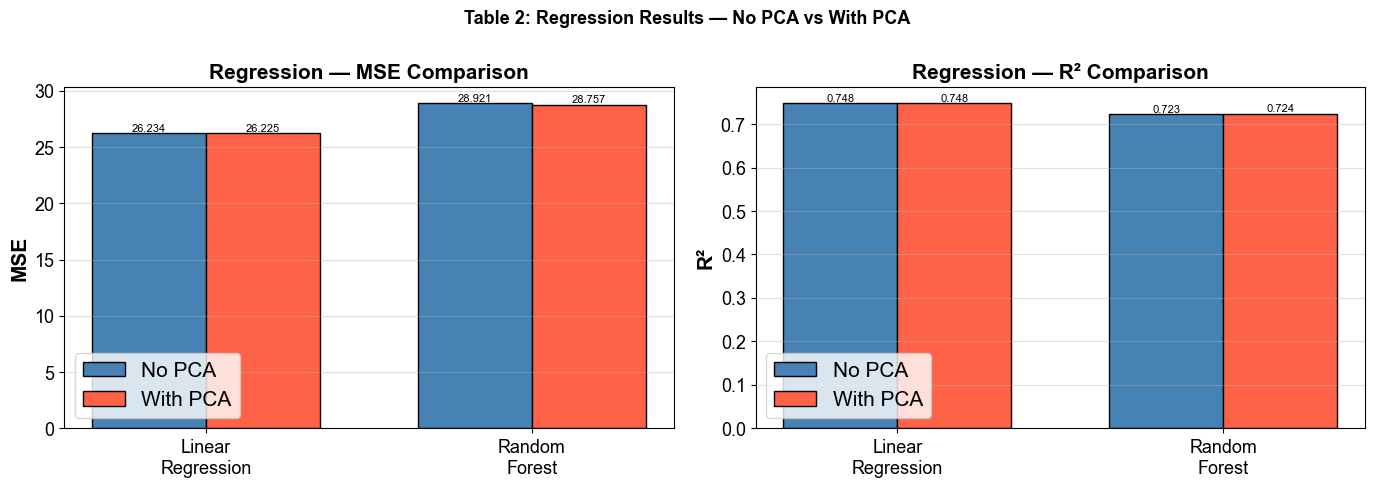

Saved: regression_comparison.png


In [28]:
# SECTION 7: VISUALIZATIONS

# ── 7a. Regression Metrics Bar Chart ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
reg_models  = ["Linear\nRegression", "Random\nForest"]
mse_no_list  = [lr_mse_no.mean(),  rf_mse_no.mean()]
mse_pca_list = [lr_mse_pca.mean(), rf_mse_pca.mean()]
r2_no_list   = [lr_r2_no.mean(),   rf_r2_no.mean()]
r2_pca_list  = [lr_r2_pca.mean(),  rf_r2_pca.mean()]
 
x = np.arange(len(reg_models)); w = 0.35
axes[0].bar(x - w/2, mse_no_list,  w, label="No PCA",   color="steelblue", edgecolor="black")
axes[0].bar(x + w/2, mse_pca_list, w, label="With PCA", color="tomato",    edgecolor="black")
axes[0].set_title("Regression — MSE Comparison", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(reg_models)
axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.4)
for i, (a, b) in enumerate(zip(mse_no_list, mse_pca_list)):
    axes[0].text(i - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
 
axes[1].bar(x - w/2, r2_no_list,  w, label="No PCA",   color="steelblue", edgecolor="black")
axes[1].bar(x + w/2, r2_pca_list, w, label="With PCA", color="tomato",    edgecolor="black")
axes[1].set_title("Regression — R² Comparison", fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(reg_models)
axes[1].set_ylabel("R²"); axes[1].legend(); axes[1].grid(axis="y", alpha=0.4)
for i, (a, b) in enumerate(zip(r2_no_list, r2_pca_list)):
    axes[1].text(i - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    axes[1].text(i + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
 
plt.suptitle("Table 2: Regression Results — No PCA vs With PCA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regression_comparison.png", dpi=150)
plt.show()
print("Saved: regression_comparison.png")

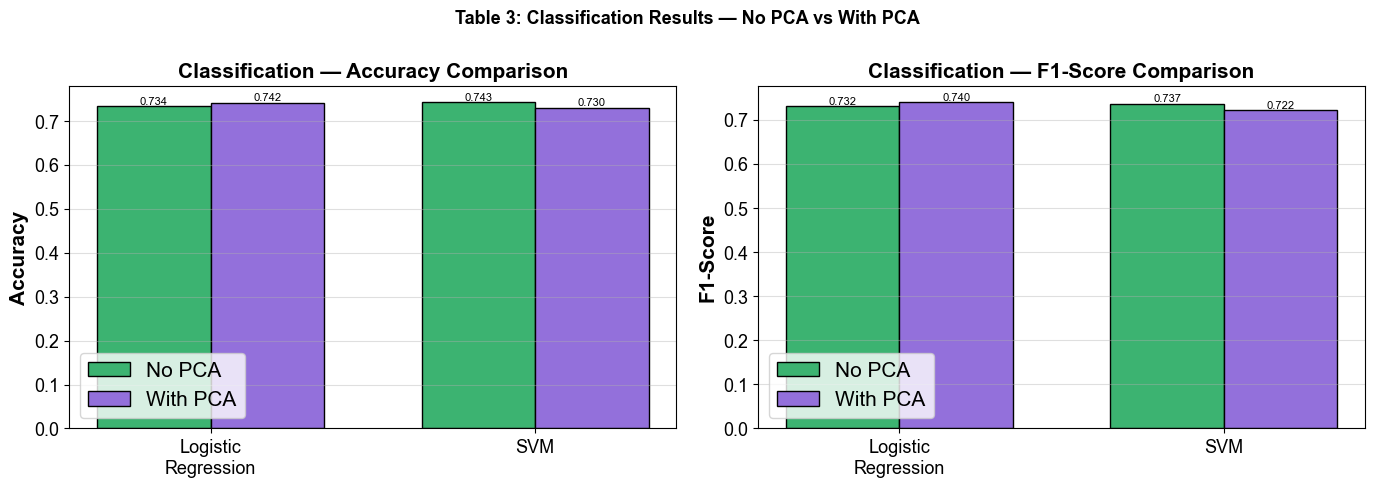

Saved: classification_comparison.png


In [29]:
# ── 7b. Classification Metrics Bar Chart ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
clf_models   = ["Logistic\nRegression", "SVM"]
acc_no_list  = [lr_acc_no.mean(),  svm_acc_no.mean()]
acc_pca_list = [lr_acc_pca.mean(), svm_acc_pca.mean()]
f1_no_list   = [lr_f1_no.mean(),   svm_f1_no.mean()]
f1_pca_list  = [lr_f1_pca.mean(),  svm_f1_pca.mean()]
 
axes[0].bar(x - w/2, acc_no_list,  w, label="No PCA",   color="mediumseagreen", edgecolor="black")
axes[0].bar(x + w/2, acc_pca_list, w, label="With PCA", color="mediumpurple",   edgecolor="black")
axes[0].set_title("Classification — Accuracy Comparison", fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(clf_models)
axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.4)
for i, (a, b) in enumerate(zip(acc_no_list, acc_pca_list)):
    axes[0].text(i - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
 
axes[1].bar(x - w/2, f1_no_list,  w, label="No PCA",   color="mediumseagreen", edgecolor="black")
axes[1].bar(x + w/2, f1_pca_list, w, label="With PCA", color="mediumpurple",   edgecolor="black")
axes[1].set_title("Classification — F1-Score Comparison", fontweight="bold")
axes[1].set_xticks(x); axes[1].set_xticklabels(clf_models)
axes[1].set_ylabel("F1-Score"); axes[1].legend(); axes[1].grid(axis="y", alpha=0.4)
for i, (a, b) in enumerate(zip(f1_no_list, f1_pca_list)):
    axes[1].text(i - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    axes[1].text(i + w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
 
plt.suptitle("Table 3: Classification Results — No PCA vs With PCA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("classification_comparison.png", dpi=150)
plt.show()
print("Saved: classification_comparison.png")
 

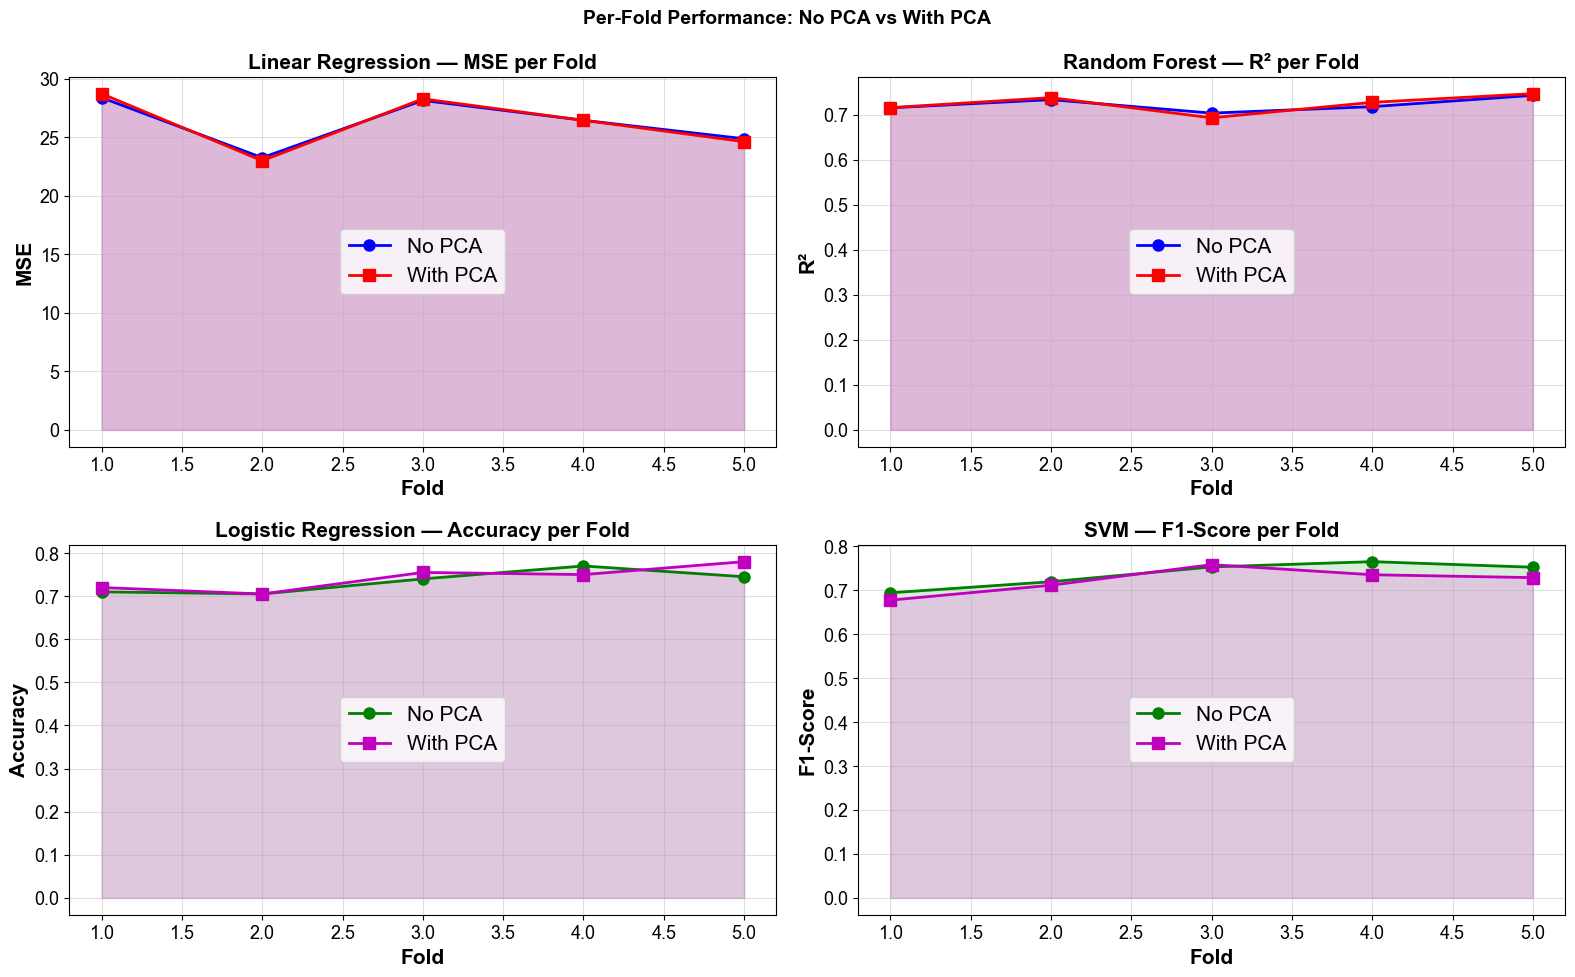

Saved: per_fold_comparison.png


In [30]:
# ── 7c. Per-Fold Variance Plot ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
folds = [1, 2, 3, 4, 5]
 
# LR MSE per fold
axes[0, 0].plot(folds, lr_mse_no,  "bo-", label="No PCA",   linewidth=2, markersize=8)
axes[0, 0].plot(folds, lr_mse_pca, "rs-", label="With PCA", linewidth=2, markersize=8)
axes[0, 0].fill_between(folds, lr_mse_no,  alpha=0.15, color="blue")
axes[0, 0].fill_between(folds, lr_mse_pca, alpha=0.15, color="red")
axes[0, 0].set_title("Linear Regression — MSE per Fold", fontweight="bold")
axes[0, 0].set_xlabel("Fold"); axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.4)
 
# RF R2 per fold
axes[0, 1].plot(folds, rf_r2_no,  "bo-", label="No PCA",   linewidth=2, markersize=8)
axes[0, 1].plot(folds, rf_r2_pca, "rs-", label="With PCA", linewidth=2, markersize=8)
axes[0, 1].fill_between(folds, rf_r2_no,  alpha=0.15, color="blue")
axes[0, 1].fill_between(folds, rf_r2_pca, alpha=0.15, color="red")
axes[0, 1].set_title("Random Forest — R² per Fold", fontweight="bold")
axes[0, 1].set_xlabel("Fold"); axes[0, 1].set_ylabel("R²")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.4)
 
# Logistic Reg Acc per fold
axes[1, 0].plot(folds, lr_acc_no,  "go-", label="No PCA",   linewidth=2, markersize=8)
axes[1, 0].plot(folds, lr_acc_pca, "ms-", label="With PCA", linewidth=2, markersize=8)
axes[1, 0].fill_between(folds, lr_acc_no,  alpha=0.15, color="green")
axes[1, 0].fill_between(folds, lr_acc_pca, alpha=0.15, color="magenta")
axes[1, 0].set_title("Logistic Regression — Accuracy per Fold", fontweight="bold")
axes[1, 0].set_xlabel("Fold"); axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.4)
 
# SVM F1 per fold
axes[1, 1].plot(folds, svm_f1_no,  "go-", label="No PCA",   linewidth=2, markersize=8)
axes[1, 1].plot(folds, svm_f1_pca, "ms-", label="With PCA", linewidth=2, markersize=8)
axes[1, 1].fill_between(folds, svm_f1_no,  alpha=0.15, color="green")
axes[1, 1].fill_between(folds, svm_f1_pca, alpha=0.15, color="magenta")
axes[1, 1].set_title("SVM — F1-Score per Fold", fontweight="bold")
axes[1, 1].set_xlabel("Fold"); axes[1, 1].set_ylabel("F1-Score")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.4)
 
plt.suptitle("Per-Fold Performance: No PCA vs With PCA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("per_fold_comparison.png", dpi=150)
plt.show()
print("Saved: per_fold_comparison.png")

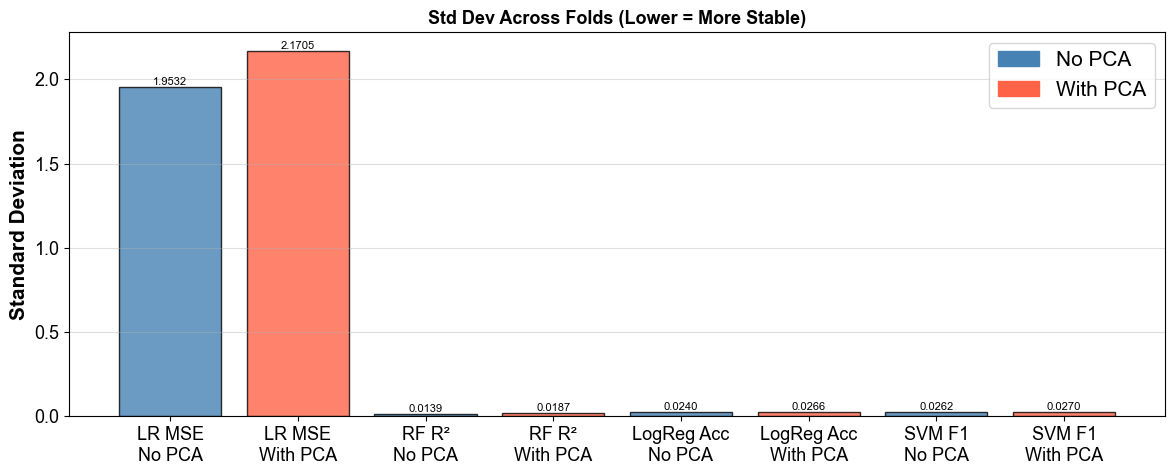

Saved: variance_comparison.png


In [31]:
# ── 7d. Variance Across Folds ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
labels_var  = ["LR MSE\nNo PCA", "LR MSE\nWith PCA",
                "RF R²\nNo PCA",  "RF R²\nWith PCA",
                "LogReg Acc\nNo PCA", "LogReg Acc\nWith PCA",
                "SVM F1\nNo PCA", "SVM F1\nWith PCA"]
variances = [lr_mse_no.std(), lr_mse_pca.std(),
             rf_r2_no.std(),  rf_r2_pca.std(),
             lr_acc_no.std(), lr_acc_pca.std(),
             svm_f1_no.std(), svm_f1_pca.std()]
colors_var = ["steelblue", "tomato"] * 4
bars = ax.bar(labels_var, variances, color=colors_var, edgecolor="black", alpha=0.8)
ax.set_title("Std Dev Across Folds (Lower = More Stable)", fontsize=13, fontweight="bold")
ax.set_ylabel("Standard Deviation")
ax.grid(axis="y", alpha=0.4)
for bar, val in zip(bars, variances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="steelblue", label="No PCA"),
                   Patch(color="tomato",    label="With PCA")], loc="upper right")
plt.tight_layout()
plt.savefig("variance_comparison.png", dpi=150)
plt.show()
print("Saved: variance_comparison.png")

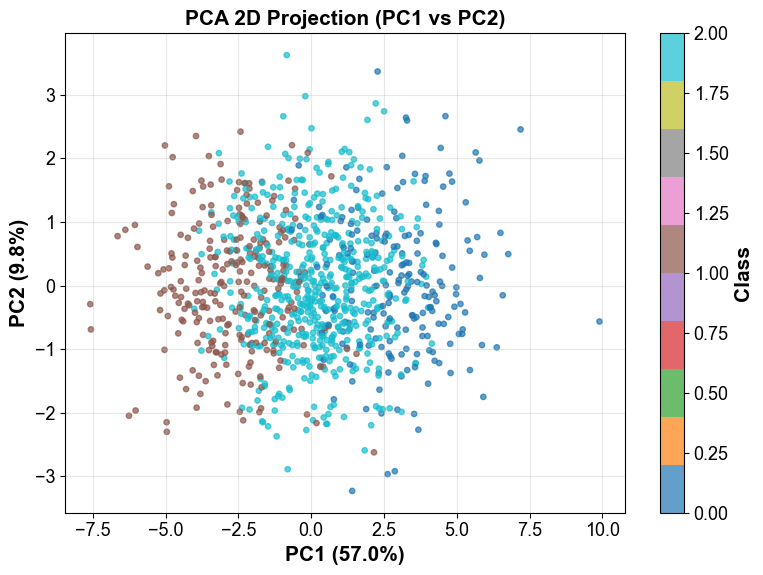

Saved: pca_2d_scatter.png


In [32]:
# ── 7e. PCA 2D Scatter (first 2 PCs) ─────────────────────────
if n_components_95 >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(X_pca.iloc[:, 0], X_pca.iloc[:, 1],
                    c=y_clf_s, cmap="tab10", s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label="Class")
    ax.set_title("PCA 2D Projection (PC1 vs PC2)", fontweight="bold")
    ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("pca_2d_scatter.png", dpi=150)
    plt.show()
    print("Saved: pca_2d_scatter.png")

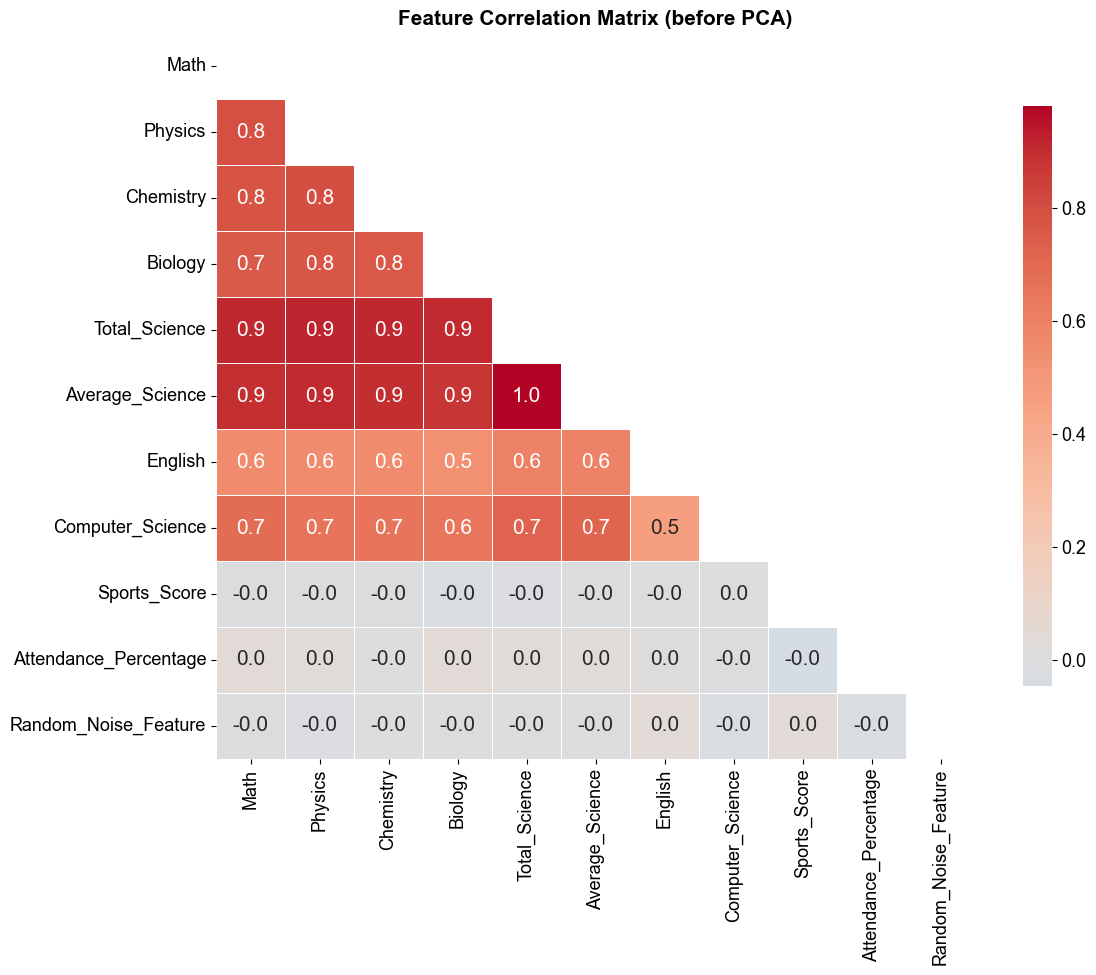

Saved: feature_correlation_heatmap.png


In [33]:
import seaborn as sns
# ── 7f. Feature Correlation Heatmap (before PCA) ─────────────
if X_raw.shape[1] <= 30:
    fig, ax = plt.subplots(figsize=(12, 10))
    corr = X_raw.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
                annot=X_raw.shape[1] <= 15,
                fmt=".1f", linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Feature Correlation Matrix (before PCA)", fontweight="bold")
    plt.tight_layout()
    plt.savefig("feature_correlation_heatmap.png", dpi=150)
    plt.show()
    print("Saved: feature_correlation_heatmap.png")

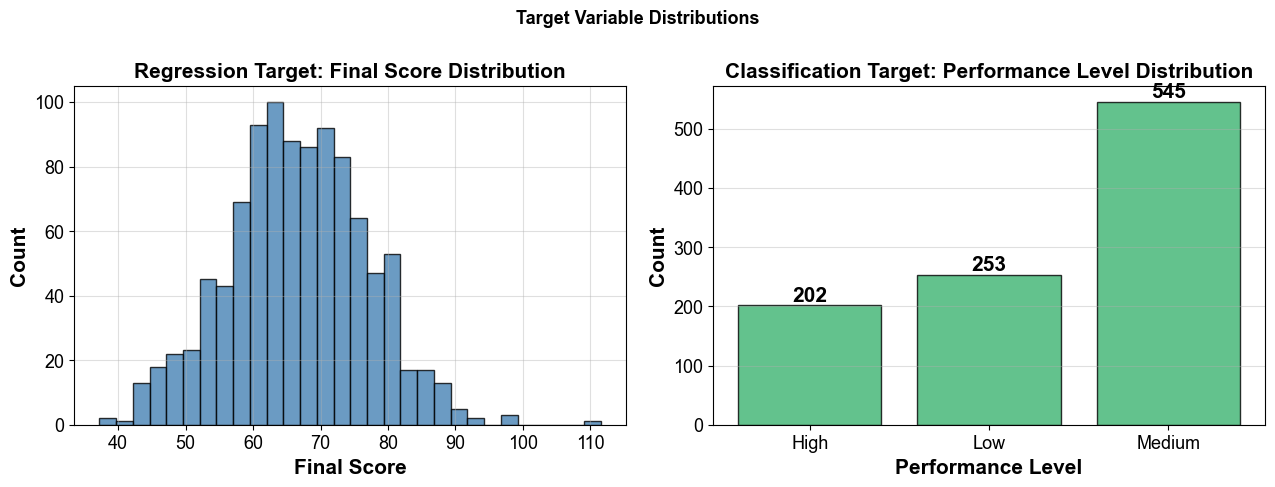

Saved: target_distributions.png


In [34]:
# ── 7g. Target Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(y_reg, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Regression Target: Final Score Distribution", fontweight="bold")
axes[0].set_xlabel("Final Score"); axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.4)
 
cls_counts = pd.Series(y_clf_enc).value_counts().sort_index()
axes[1].bar([le.classes_[i] for i in cls_counts.index], cls_counts.values,
            color="mediumseagreen", edgecolor="black", alpha=0.8)
axes[1].set_title("Classification Target: Performance Level Distribution", fontweight="bold")
axes[1].set_xlabel("Performance Level"); axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.4)
for i, v in enumerate(cls_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")
 
plt.suptitle("Target Variable Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("target_distributions.png", dpi=150)
plt.show()
print("Saved: target_distributions.png")

In [35]:
lr_mse_improved  = lr_mse_pca.mean() < lr_mse_no.mean()
rf_r2_changed    = abs(rf_r2_pca.mean() - rf_r2_no.mean())
logreg_improved  = lr_acc_pca.mean() > lr_acc_no.mean()
svm_improved     = svm_acc_pca.mean() > svm_acc_no.mean()
lr_var_reduced   = lr_mse_pca.std() < lr_mse_no.std()
 
print(f"""
Q1. Did PCA improve Linear Regression performance?
    → MSE No PCA={lr_mse_no.mean():.4f}  |  MSE With PCA={lr_mse_pca.mean():.4f}
    → {'YES' if lr_mse_improved else 'NO'}: PCA {'reduced' if lr_mse_improved else 'did not reduce'} MSE.
      Linear Regression benefits from PCA when features are multicollinear,
      as PCA decorrelates them and removes noise dimensions.
 
Q2. Did PCA significantly affect Random Forest?
    → R² change = {rf_r2_changed:.4f} (No PCA={rf_r2_no.mean():.4f}  |  With PCA={rf_r2_pca.mean():.4f})
    → Change is {'significant' if rf_r2_changed > 0.02 else 'minimal'}.
      Tree-based models use feature splits and are less sensitive to
      multicollinearity; PCA may even hurt by creating abstract components.
 
Q3. Which classification model benefited more from PCA?
    → Logistic Regression gain: {(lr_acc_pca.mean()-lr_acc_no.mean())*100:+.2f}% accuracy
    → SVM gain               : {(svm_acc_pca.mean()-svm_acc_no.mean())*100:+.2f}% accuracy
    → {'Logistic Regression' if (lr_acc_pca.mean()-lr_acc_no.mean()) >= (svm_acc_pca.mean()-svm_acc_no.mean()) else 'SVM'} benefited more from PCA.
 
Q4. Did PCA reduce variance across folds?
    → LR MSE std: No PCA={lr_mse_no.std():.4f}  |  With PCA={lr_mse_pca.std():.4f}
    → {'YES' if lr_var_reduced else 'NO'}: PCA {'stabilised' if lr_var_reduced else 'did not stabilise'} fold performance.
      By removing noise dimensions, PCA often reduces variance in CV results.
 
Q5. Why do linear models benefit more from PCA than ensemble models?
    → Linear models assume feature independence and suffer from multicollinearity.
      PCA orthogonalises features (zero correlation), which directly helps.
      Ensemble (tree) models split one feature at a time, making them immune
      to multicollinearity. PCA's loss of interpretability (abstract PCs)
      doesn't compensate for any gain in tree-based methods.
""")
 


Q1. Did PCA improve Linear Regression performance?
    → MSE No PCA=26.2338  |  MSE With PCA=26.2251
    → YES: PCA reduced MSE.
      Linear Regression benefits from PCA when features are multicollinear,
      as PCA decorrelates them and removes noise dimensions.

Q2. Did PCA significantly affect Random Forest?
    → R² change = 0.0015 (No PCA=0.7225  |  With PCA=0.7241)
    → Change is minimal.
      Tree-based models use feature splits and are less sensitive to
      multicollinearity; PCA may even hurt by creating abstract components.

Q3. Which classification model benefited more from PCA?
    → Logistic Regression gain: +0.80% accuracy
    → SVM gain               : -1.30% accuracy
    → Logistic Regression benefited more from PCA.

Q4. Did PCA reduce variance across folds?
    → LR MSE std: No PCA=1.9532  |  With PCA=2.1705
    → NO: PCA did not stabilise fold performance.
      By removing noise dimensions, PCA often reduces variance in CV results.

Q5. Why do linear models b